# Baseline CNN

Execução do pipeline experimental reutilizável da CNN baseline no PlantVillage. O treinamento e todas as análises desta etapa usam somente os conjuntos de treino e validação. **O conjunto de teste permanece reservado para a avaliação final e não é avaliado neste notebook.**

## Caminhos e ambiente

A célula abaixo localiza o projeto localmente. No Google Colab, ela monta o Drive e usa `MyDrive/plant-disease-classification` por padrão, clonando automaticamente o repositório quando necessário. Assim, dados e resultados persistem após o encerramento do runtime. Para usar apenas o armazenamento temporário de `/content`, defina `MOUNT_DRIVE = False`. Todos os artefatos da execução ficam em `results/baseline_cnn/`.

In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

REPOSITORY_URL = "https://github.com/murilodc/plant-disease-classification.git"
COLAB_PROJECT_DIR = Path("/content/plant-disease-classification")
LEGACY_COLAB_PROJECT_DIR = Path("/content/tcc-plant-disease-classification")
DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/plant-disease-classification")
LEGACY_DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/TCC")
AUTO_CLONE_REPOSITORY = True
MOUNT_DRIVE = True
if IN_COLAB and MOUNT_DRIVE:
    drive.mount("/content/drive")


def is_project_root(path: Path) -> bool:
    return (path / "src" / "plantvillage_pytorch.py").is_file()


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    if IN_COLAB:
        candidates.extend(
            [
                DRIVE_PROJECT_DIR,
                LEGACY_DRIVE_PROJECT_DIR,
                COLAB_PROJECT_DIR,
                LEGACY_COLAB_PROJECT_DIR,
            ]
        )

    for candidate in candidates:
        if is_project_root(candidate):
            return candidate

    if IN_COLAB and AUTO_CLONE_REPOSITORY:
        clone_target = DRIVE_PROJECT_DIR if MOUNT_DRIVE else COLAB_PROJECT_DIR
        if clone_target.exists():
            raise FileNotFoundError(
                f"{clone_target} já existe, mas não contém o projeto completo. "
                "Remova ou renomeie esse diretório e execute a célula novamente."
            )
        print("Clonando o repositório para o runtime do Colab...")
        subprocess.check_call(
            ["git", "clone", "--depth", "1", REPOSITORY_URL, str(clone_target)]
        )
        if is_project_root(clone_target):
            return clone_target

    raise FileNotFoundError(
        "Projeto não encontrado. Envie o repositório completo ao Colab, "
        "monte o Google Drive ou habilite AUTO_CLONE_REPOSITORY."
    )


BASE_DIR = find_project_root()
DATA_DIR = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"
BASELINE_RESULTS_DIR = RESULTS_DIR / "baseline_cnn"
SRC_DIR = BASE_DIR / "src"

# Ajuste estes caminhos se os arquivos estiverem em outro local no Colab.
ZIP_PATH = DATA_DIR / "data.zip"
LEAF_MAP_PATH = DATA_DIR / "leaf_grouping" / "leaf-map.json"
RAW_METADATA_CSV = RESULTS_DIR / "plantvillage_metadata_raw_color.csv"
METADATA_CSV = RESULTS_DIR / "plantvillage_metadata_split.csv"
IMAGE_ROOT = Path("/content/plantvillage_color") if IN_COLAB else DATA_DIR / "plantvillage_color"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
BASELINE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if not SRC_DIR.exists():
    raise FileNotFoundError(f"Diretório src não encontrado: {SRC_DIR}")

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Base:", BASE_DIR)
print("Dados:", DATA_DIR)
print("Resultados da baseline:", BASELINE_RESULTS_DIR)
print("Imagens:", IMAGE_ROOT)

Mounted at /content/drive
Base: /content/drive/MyDrive/plant-disease-classification
Dados: /content/drive/MyDrive/plant-disease-classification/data
Resultados da baseline: /content/drive/MyDrive/plant-disease-classification/results/baseline_cnn
Imagens: /content/plantvillage_color


## Dependências

As dependências ausentes são instaladas automaticamente. O nome de importação `sklearn` corresponde ao pacote `scikit-learn`.

In [2]:
required_packages = {
    "torch": "torch",
    "torchvision": "torchvision",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
}
missing_packages = [
    package
    for module_name, package in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing_packages])

import json

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import Image, display

## Configuração da execução

In [3]:
SEED = 42
NUM_CLASSES = 38
BATCH_SIZE = 32
MAX_EPOCHS = 30
LEARNING_RATE = 0.001
EARLY_STOPPING_PATIENCE = 5
MIN_DELTA = 1e-4
NUM_WORKERS = 2 if IN_COLAB else 0
REQUIRE_CUDA_IN_COLAB = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if IN_COLAB and REQUIRE_CUDA_IN_COLAB and device.type != "cuda":
    raise RuntimeError(
        "GPU não disponível. No Colab, selecione Ambiente de execução > "
        "Alterar tipo de ambiente de execução > T4 GPU e execute novamente."
    )
print("Dispositivo selecionado automaticamente:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Dispositivo selecionado automaticamente: cuda
GPU: Tesla T4


In [4]:
from plantvillage_audit import build_metadata_dataframe, save_metadata_csv
from plantvillage_pytorch import extract_raw_color_from_zip
from plantvillage_split import save_split_metadata_csv, split_metadata_by_leaf_id
from train_baseline import train_baseline

## Download, metadados e extração do PlantVillage

Esta etapa reaproveita as rotinas existentes no projeto. Downloads, geração do CSV de splits e extração só acontecem quando os respectivos arquivos ainda não existem.

In [5]:
DOWNLOAD_DATA_IF_MISSING = True
EXTRACT_IMAGES_IF_MISSING = True

if DOWNLOAD_DATA_IF_MISSING and (not ZIP_PATH.exists() or not LEAF_MAP_PATH.exists()):
    if importlib.util.find_spec("huggingface_hub") is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "huggingface_hub"])
    from huggingface_hub import hf_hub_download

    DATA_DIR.mkdir(parents=True, exist_ok=True)
    if not ZIP_PATH.exists():
        ZIP_PATH = Path(
            hf_hub_download(
                repo_id="mohanty/PlantVillage",
                filename="data.zip",
                repo_type="dataset",
                local_dir=str(DATA_DIR),
            )
        )
    if not LEAF_MAP_PATH.exists():
        LEAF_MAP_PATH = Path(
            hf_hub_download(
                repo_id="mohanty/PlantVillage",
                filename="leaf_grouping/leaf-map.json",
                repo_type="dataset",
                local_dir=str(DATA_DIR),
            )
        )

if not METADATA_CSV.exists():
    if not ZIP_PATH.exists() or not LEAF_MAP_PATH.exists():
        raise FileNotFoundError(
            "CSV de split ausente e arquivos base não encontrados. "
            "Ajuste ZIP_PATH e LEAF_MAP_PATH para os caminhos corretos."
        )
    print("CSV de split ausente; gerando com a lógica atual do repositório.")
    metadata = build_metadata_dataframe(ZIP_PATH, LEAF_MAP_PATH)
    save_metadata_csv(metadata, RAW_METADATA_CSV)
    metadata_split = split_metadata_by_leaf_id(metadata)
    save_split_metadata_csv(metadata_split, METADATA_CSV)
else:
    print("CSV de split encontrado:", METADATA_CSV)

if EXTRACT_IMAGES_IF_MISSING:
    if not ZIP_PATH.exists():
        raise FileNotFoundError(f"ZIP não encontrado para extração: {ZIP_PATH}")
    print("Verificando/completando imagens raw/color em:", IMAGE_ROOT)
    extraction_summary = extract_raw_color_from_zip(ZIP_PATH, IMAGE_ROOT)
    print(extraction_summary)
    if int(extraction_summary['total']) != 54_305:
        raise RuntimeError("Extração incompleta: esperadas 54.305 imagens raw/color.")
elif not IMAGE_ROOT.is_dir() or not any(IMAGE_ROOT.iterdir()):
    raise FileNotFoundError(f"Diretório de imagens vazio ou ausente: {IMAGE_ROOT}")

data.zip:   0%|          | 0.00/2.18G [00:00<?, ?B/s]

leaf-map.json:   0%|          | 0.00/2.43M [00:00<?, ?B/s]

CSV de split ausente; gerando com a lógica atual do repositório.
Verificando/completando imagens raw/color em: /content/plantvillage_color
{'output_dir': '/content/plantvillage_color', 'extracted': 54305, 'skipped': 0, 'total': 54305}


## Conferência dos splits

A tabela é apenas uma conferência dos metadados. O split `test` não é usado no treinamento, na seleção do checkpoint, na cronometragem de inferência nem no cálculo das métricas abaixo.

In [6]:
metadata_df = pd.read_csv(METADATA_CSV)
required_columns = {'zip_path', 'classe', 'leaf_id', 'split'}
missing_columns = sorted(required_columns - set(metadata_df.columns))
if missing_columns:
    raise KeyError(f"Colunas ausentes no CSV de split: {missing_columns}")
expected_split_sizes = {'train': 38_008, 'validation': 8_172, 'test': 8_125}
actual_split_sizes = metadata_df['split'].value_counts().to_dict()
if actual_split_sizes != expected_split_sizes:
    raise ValueError(f"Tamanhos de split inesperados: {actual_split_sizes}")
if metadata_df['classe'].nunique() != 38:
    raise ValueError("O CSV de split deve conter exatamente 38 classes.")
if metadata_df.groupby('leaf_id')['split'].nunique().max() != 1:
    raise ValueError("Data leakage: há leaf_id presente em mais de um split.")

split_sizes = (
    metadata_df["split"]
    .value_counts()
    .rename_axis("split")
    .reset_index(name="num_images")
)
display(split_sizes)
print("Avaliação durante o desenvolvimento: validation")
print("Avaliação final reservada: test (não utilizado neste notebook)")

,split,num_images
0,train,38008
1,validation,8172
2,test,8125


Avaliação durante o desenvolvimento: validation
Avaliação final reservada: test (não utilizado neste notebook)


## Treinamento e avaliação da baseline

`train_baseline` concentra a criação dos DataLoaders e do modelo, o resumo programático da arquitetura, o treinamento cronometrado, a restauração do melhor checkpoint e a avaliação completa na validação. Em CUDA, a função também faz sincronização para as medições e warm-up antes da inferência cronometrada.

In [7]:
model, history, checkpoint_path = train_baseline(
    metadata_csv=METADATA_CSV,
    image_root=IMAGE_ROOT,
    output_dir=BASELINE_RESULTS_DIR,
    batch_size=BATCH_SIZE,
    epochs=MAX_EPOCHS,
    learning_rate=LEARNING_RATE,
    num_classes=NUM_CLASSES,
    num_workers=NUM_WORKERS,
    seed=SEED,
    patience=EARLY_STOPPING_PATIENCE,
    min_delta=MIN_DELTA,
)

print("Melhor checkpoint:", checkpoint_path)

Device: cuda
BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.1, inplace=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.15, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout2d(p=0.2, inplace=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout2d(p=0.25, inplace=False)
  )
  (pool): AdaptiveAvgP

## Arquitetura registrada

O resumo salvo contém parâmetros totais e treináveis, convoluções, pooling, dropout, classificador final e número de classes de saída.

In [8]:
architecture_path = BASELINE_RESULTS_DIR / "architecture_summary.json"
with architecture_path.open(encoding="utf-8") as architecture_file:
    architecture = json.load(architecture_file)

print(model)
display(
    pd.Series(
        {
            "model_class": architecture["model_class"],
            "total_parameters": architecture["total_parameters"],
            "trainable_parameters": architecture["trainable_parameters"],
            "num_convolutional_layers": architecture["num_convolutional_layers"],
            "num_output_classes": architecture["num_output_classes"],
        },
        name="architecture",
    ).to_frame()
)
display(pd.DataFrame(architecture["convolutional_layers"]))
display(pd.DataFrame(architecture["pooling_layers"]))
display(pd.DataFrame(architecture["dropout_layers"]))
display(pd.DataFrame([architecture["classification_layer"]]))

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.1, inplace=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.15, inplace=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Dropout2d(p=0.2, inplace=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout2d(p=0.25, inplace=False)
  )
  (pool): AdaptiveAvgPool2d(output_

,architecture
model_class,BaselineCNN
total_parameters,398182
trainable_parameters,398182
num_convolutional_layers,4
num_output_classes,38


,name,type,in_channels,out_channels,kernel_size,stride,padding
0,features.0,Conv2d,3,32,"[3, 3]","[1, 1]","[1, 1]"
1,features.4,Conv2d,32,64,"[3, 3]","[1, 1]","[1, 1]"
2,features.8,Conv2d,64,128,"[3, 3]","[1, 1]","[1, 1]"
3,features.12,Conv2d,128,256,"[3, 3]","[1, 1]","[1, 1]"


,name,type,kernel_size,stride,padding,output_size
0,features.2,MaxPool2d,2.0,2.0,0.0,NaN
1,features.6,MaxPool2d,2.0,2.0,0.0,NaN
2,features.10,MaxPool2d,2.0,2.0,0.0,NaN
3,features.14,MaxPool2d,2.0,2.0,0.0,NaN
4,pool,AdaptiveAvgPool2d,NaN,NaN,NaN,"[1, 1]"


,name,type,p
0,features.3,Dropout2d,0.10
1,features.7,Dropout2d,0.15
2,features.11,Dropout2d,0.20
3,features.15,Dropout2d,0.25
4,classifier.1,Dropout,0.50


,name,type,in_features,out_features
0,classifier.2,Linear,256,38


## Histórico e tempos

O histórico inclui somente as épocas executadas. O total de treinamento soma os intervalos de treino e validação das épocas. A inferência é medida de ponta a ponta sobre o DataLoader de validação, incluindo carregamento, transferência, forward e coleta das predições.

In [9]:
history_df = pd.DataFrame(history)
display(history_df)

timing_path = BASELINE_RESULTS_DIR / "timing_summary.json"
with timing_path.open(encoding="utf-8") as timing_file:
    timing_summary = json.load(timing_file)

training_timing = timing_summary["training"]
inference_timing = timing_summary["validation_inference"]
print(f"Épocas executadas: {training_timing['epochs_executed']} / {MAX_EPOCHS}")
print(f"Early stopping: {'sim' if training_timing['early_stopping'] else 'não'}")
print(f"Melhor época: {training_timing['best_epoch']}")
print(f"Melhor validation loss: {training_timing['best_validation_loss']:.6f}")
print(f"Tempo total de treinamento: {training_timing['total_time_seconds']:.2f} s")
print(f"Tempo médio por época: {training_timing['average_time_per_epoch_seconds']:.2f} s")
print(f"Tempo total de inferência (validation): {inference_timing['total_time_seconds']:.4f} s")
print(
    "Tempo médio por imagem (validation): "
    f"{inference_timing['average_time_per_image_seconds']:.8f} s"
)
print(
    "Throughput (validation): "
    f"{inference_timing['throughput_images_per_second']:.2f} imagens/s"
)
print(f"Warm-up CUDA executado: {inference_timing['warmup_batches']} batch(es)")

,epoch,train_loss,train_accuracy,validation_loss,validation_accuracy,epoch_time_seconds
0,1,2.344227,0.358951,1.521213,0.550294,196.381040
1,2,1.544957,0.553699,1.026413,0.698972,192.728996
2,3,1.190991,0.647495,0.818037,0.758199,191.828154
3,4,1.006738,0.699879,0.661935,0.801273,192.856635
4,5,0.879319,0.736687,0.559669,0.845448,190.740945
5,6,0.796123,0.758788,0.490895,0.860866,191.133800
6,7,0.733059,0.780283,0.470356,0.861968,191.459987
7,8,0.659665,0.798069,0.418388,0.873470,190.894203
8,9,0.624101,0.809487,0.396056,0.884239,191.035719
9,10,0.599375,0.815513,0.348148,0.900636,190.739271


Épocas executadas: 30 / 30
Early stopping: não
Melhor época: 30
Melhor validation loss: 0.134906
Tempo total de treinamento: 5728.54 s
Tempo médio por época: 190.95 s
Tempo total de inferência (validation): 23.0811 s
Tempo médio por imagem (validation): 0.00282442 s
Throughput (validation): 354.06 imagens/s
Warm-up CUDA executado: 1 batch(es)


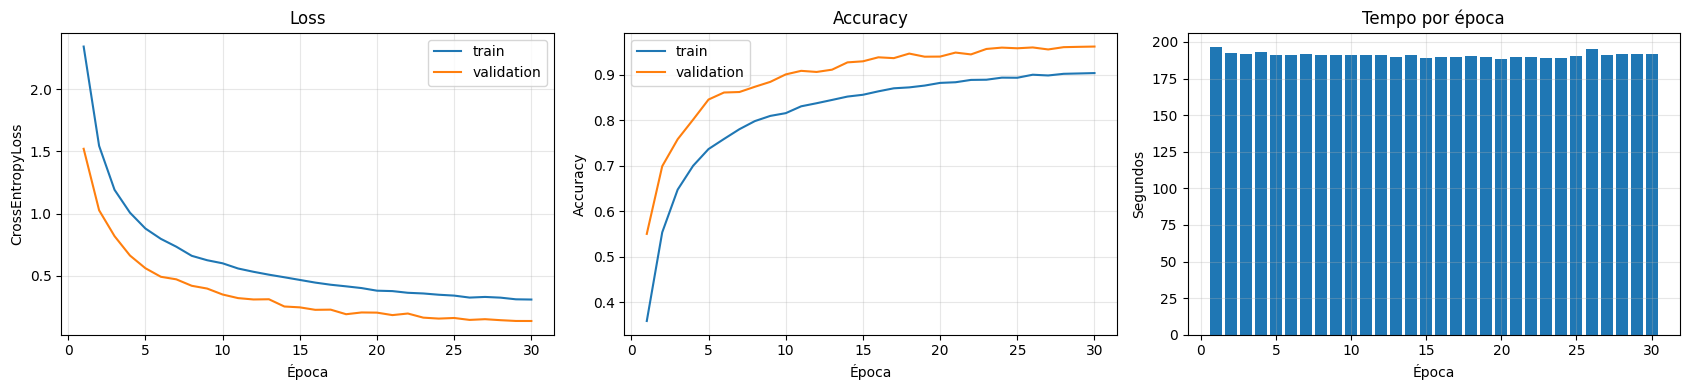

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["validation_loss"], label="validation")
axes[0].set(title="Loss", xlabel="Época", ylabel="CrossEntropyLoss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_accuracy"], label="train")
axes[1].plot(history_df["epoch"], history_df["validation_accuracy"], label="validation")
axes[1].set(title="Accuracy", xlabel="Época", ylabel="Accuracy")
axes[1].legend()

axes[2].bar(history_df["epoch"], history_df["epoch_time_seconds"])
axes[2].set(title="Tempo por época", xlabel="Época", ylabel="Segundos")

for axis in axes:
    axis.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Métricas de validação

As métricas globais incluem accuracy e agregações macro e weighted. A tabela por classe contém precision, recall, F1-score e suporte para cada uma das 38 classes.

In [11]:
validation_metrics_path = BASELINE_RESULTS_DIR / "validation_metrics.csv"
class_metrics_path = BASELINE_RESULTS_DIR / "validation_metrics_by_class.csv"

validation_metrics_df = pd.read_csv(validation_metrics_path)
class_metrics_df = pd.read_csv(class_metrics_path)

display(validation_metrics_df.T.rename(columns={0: "value"}))
display(class_metrics_df)

,value
accuracy,0.961821
precision_macro,0.955556
recall_macro,0.954360
f1_macro,0.953990
precision_weighted,0.962704
recall_weighted,0.961821
f1_weighted,0.961603
num_samples,8172.000000
num_classes,38.000000


,class_index,class_name,precision,recall,f1_score,support
0,0,Apple___Apple_scab,0.840000,0.884211,0.861538,95
1,1,Apple___Black_rot,1.000000,0.989474,0.994709,95
2,2,Apple___Cedar_apple_rust,1.000000,0.930233,0.963855,43
3,3,Apple___healthy,0.921260,0.947368,0.934132,247
4,4,Blueberry___healthy,0.957627,0.995595,0.976242,227
5,5,Cherry_(including_sour)___Powdery_mildew,0.960000,0.911392,0.935065,158
6,6,Cherry_(including_sour)___healthy,0.984375,0.969231,0.976744,130
7,7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,0.933333,0.909091,0.921053,77
8,8,Corn_(maize)___Common_rust_,1.000000,0.994413,0.997199,179
9,9,Corn_(maize)___Northern_Leaf_Blight,0.941176,0.972973,0.956811,148


## Matriz de confusão da validação

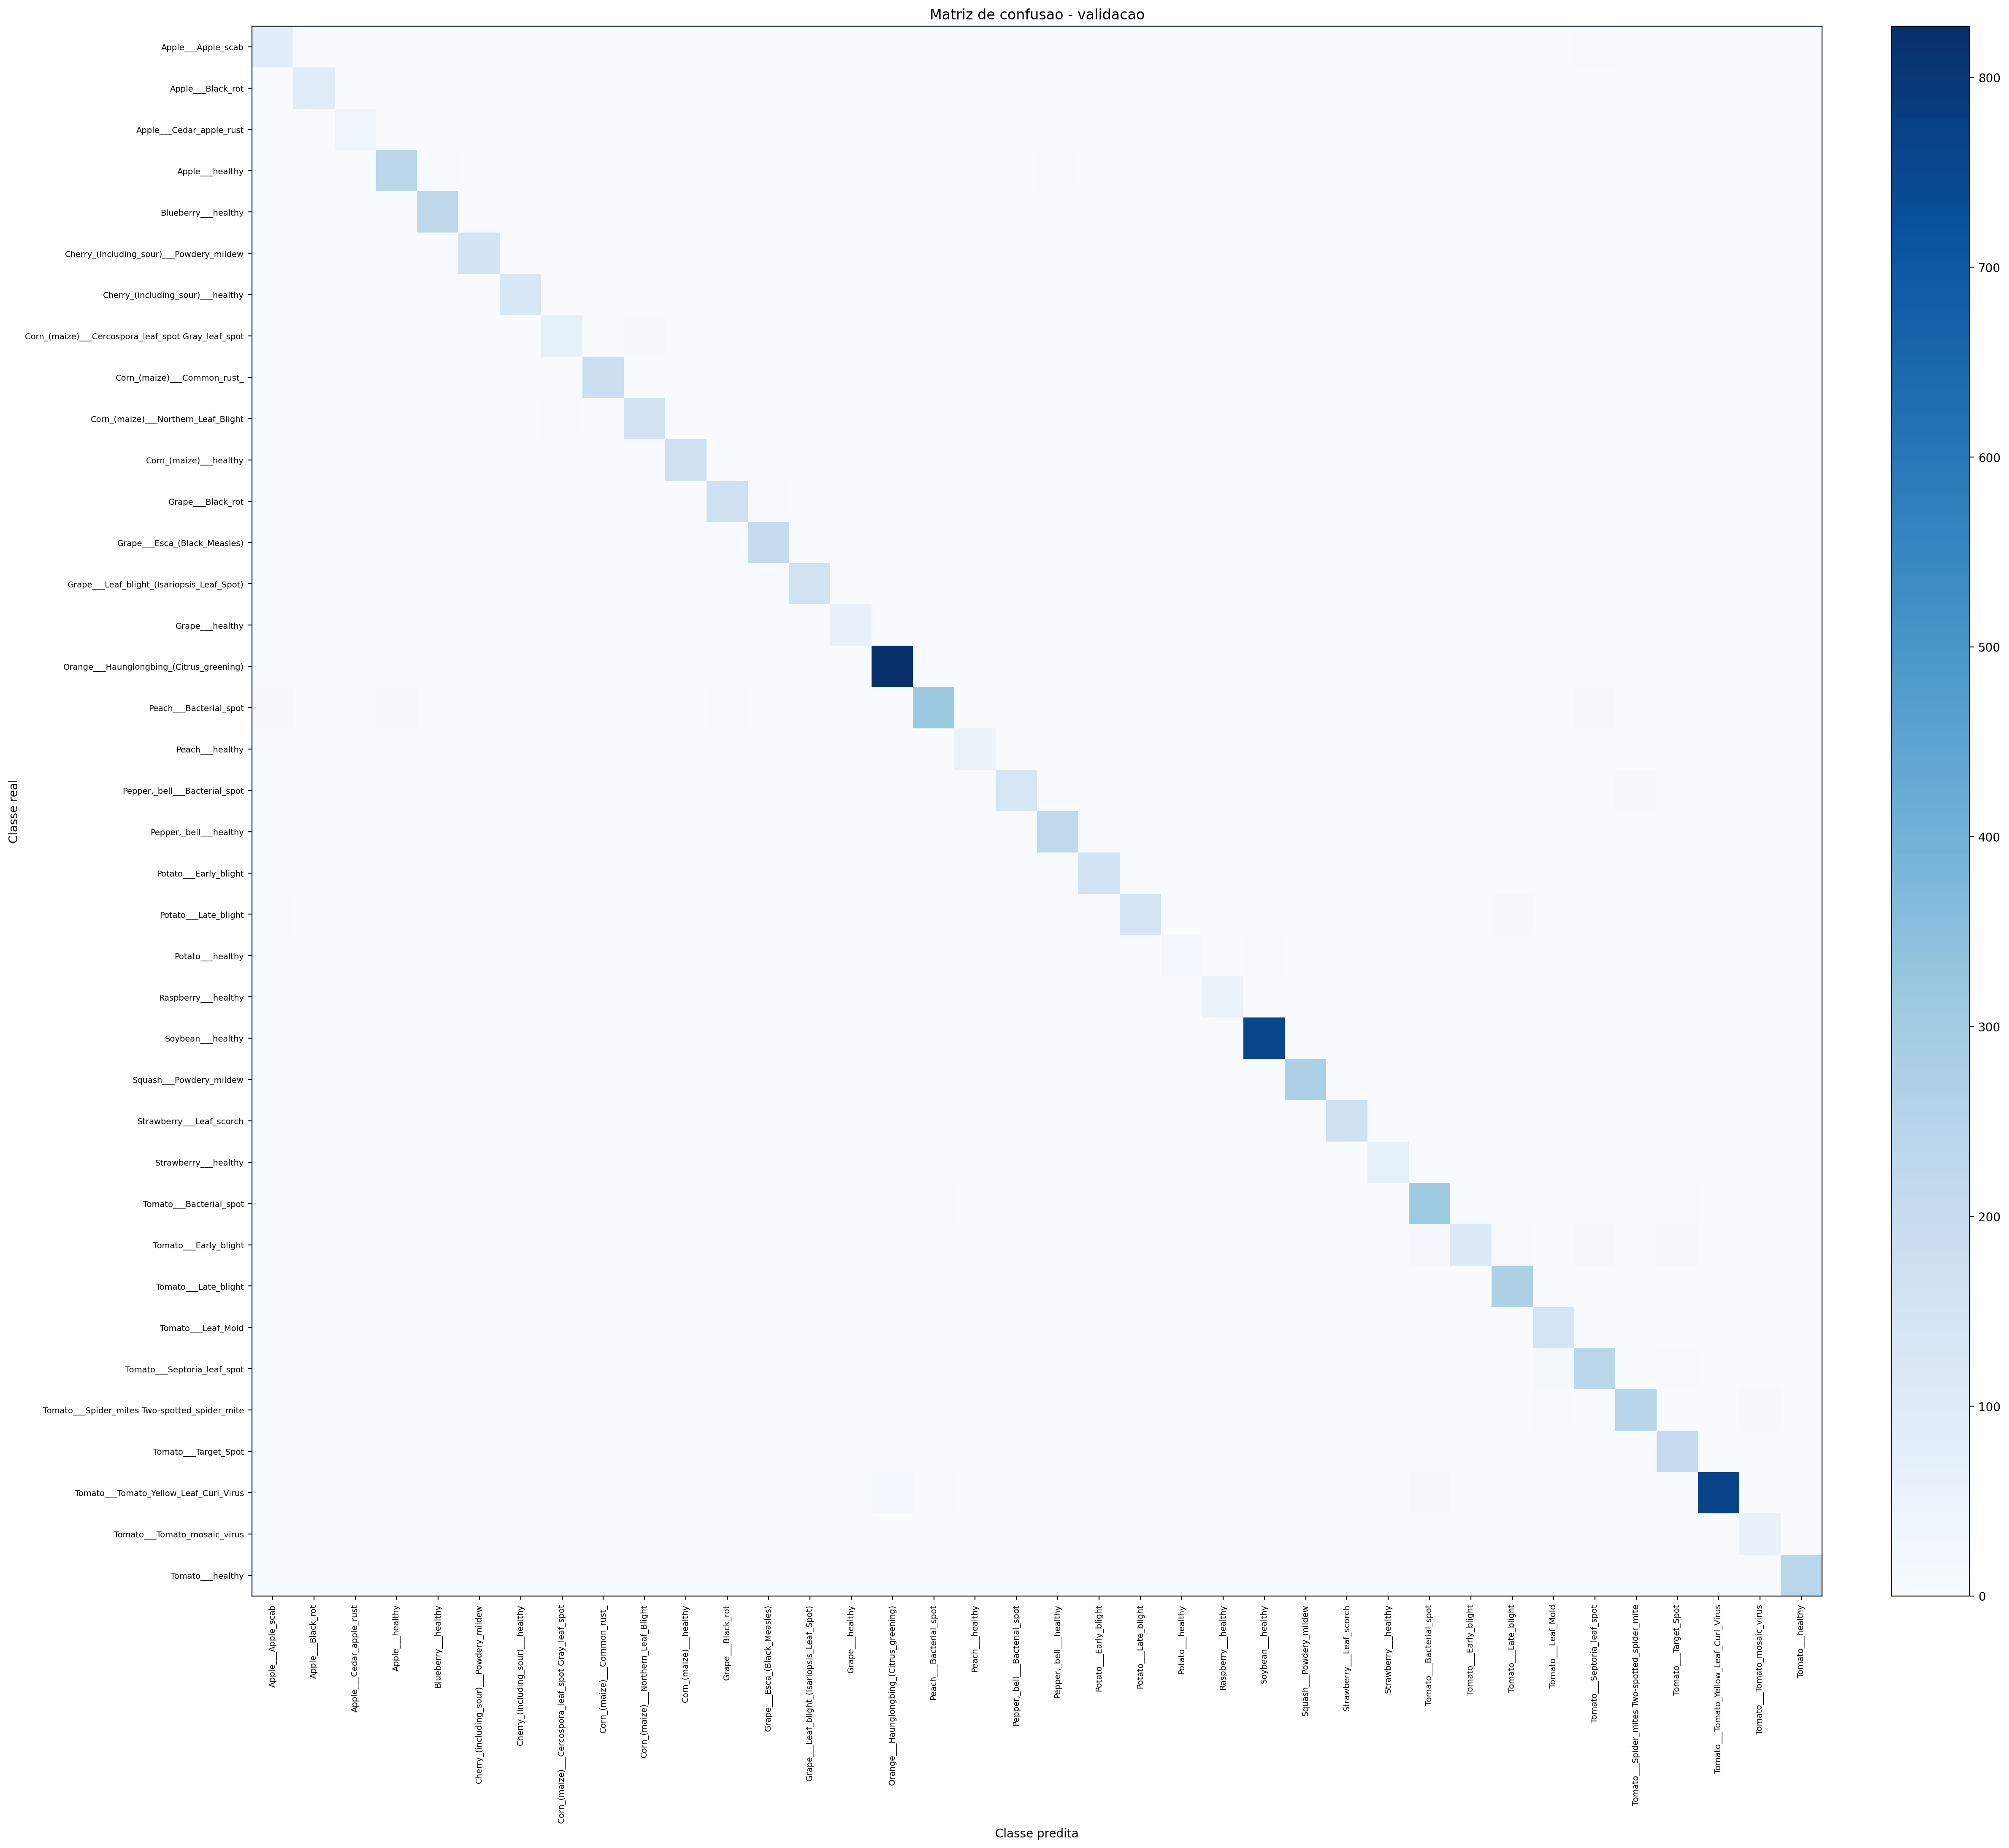

In [12]:
confusion_matrix_path = BASELINE_RESULTS_DIR / "validation_confusion_matrix.png"
display(Image(filename=str(confusion_matrix_path), width=1100))

## Artefatos gerados

In [13]:
artifacts = sorted(path for path in BASELINE_RESULTS_DIR.iterdir() if path.is_file())
artifacts_df = pd.DataFrame(
    {
        "arquivo": [path.name for path in artifacts],
        "caminho": [str(path) for path in artifacts],
        "tamanho_bytes": [path.stat().st_size for path in artifacts],
    }
)
display(artifacts_df)

metadata_path = BASELINE_RESULTS_DIR / "experiment_metadata.json"
with metadata_path.open(encoding="utf-8") as metadata_file:
    experiment_metadata = json.load(metadata_file)

print("\nBaseline CNN concluída")
print(f"Épocas executadas: {training_timing['epochs_executed']} / {MAX_EPOCHS}")
print(f"Early stopping: {'sim' if training_timing['early_stopping'] else 'não'}")
print(f"Melhor época: {training_timing['best_epoch']}")
print(f"Melhor validation loss: {training_timing['best_validation_loss']:.6f}")
print("Validation accuracy do melhor modelo: " f"{experiment_metadata['best_model_validation_accuracy']:.6f}")
print(f"Tempo total de treinamento: {training_timing['total_time_seconds']:.2f} s")
print(f"Tempo médio por época: {training_timing['average_time_per_epoch_seconds']:.2f} s")
print("Tempo médio de inferência por imagem: " f"{inference_timing['average_time_per_image_seconds']:.8f} s")
print(f"Throughput: {inference_timing['throughput_images_per_second']:.2f} imagens/s")
print(f"Parâmetros treináveis: {architecture['trainable_parameters']}")
print("Todos os resultados da baseline estão em:", BASELINE_RESULTS_DIR)

,arquivo,caminho,tamanho_bytes
0,architecture_summary.json,/content/drive/MyDrive/plant-disease-classific...,3733
1,baseline_cnn_best.pth,/content/drive/MyDrive/plant-disease-classific...,4795447
2,baseline_cnn_history.csv,/content/drive/MyDrive/plant-disease-classific...,3025
3,experiment_metadata.json,/content/drive/MyDrive/plant-disease-classific...,1898
4,timing_summary.json,/content/drive/MyDrive/plant-disease-classific...,656
5,validation_confusion_matrix.png,/content/drive/MyDrive/plant-disease-classific...,506513
6,validation_metrics.csv,/content/drive/MyDrive/plant-disease-classific...,260
7,validation_metrics_by_class.csv,/content/drive/MyDrive/plant-disease-classific...,3141



Baseline CNN concluída
Épocas executadas: 30 / 30
Early stopping: não
Melhor época: 30
Melhor validation loss: 0.134906
Validation accuracy do melhor modelo: 0.961821
Tempo total de treinamento: 5728.54 s
Tempo médio por época: 190.95 s
Tempo médio de inferência por imagem: 0.00282442 s
Throughput: 354.06 imagens/s
Parâmetros treináveis: 398182
Todos os resultados da baseline estão em: /content/drive/MyDrive/plant-disease-classification/results/baseline_cnn
